In [2]:
# Data Ingestion
%load_ext autoreload
%autoreload 2

from src.ingest import fetch_daily_grid_data
from src.config import config
import pandas as pd
import numpy as np

In [3]:
# Fetch the daily grid-level data using the updated function
df_raw = fetch_daily_grid_data(rto_code="PSCO")
# Check exactly what column names are present in your dataframe
print(df_raw.columns)

2026-06-13 18:40:28 | src.ingest | INFO | Fetching EIA data | RTO=PSCO | Start=2016-01-01 | End=None
2026-06-13 18:40:33 | src.ingest | INFO | Successfully fetched 5000 records for PSCO
Index(['period', 'respondent', 'respondent-name', 'type', 'type-name',
       'timezone', 'timezone-description', 'value', 'value-units'],
      dtype='object')


In [124]:
df_raw.shape

(5000, 9)

In [125]:
df_raw.head()

,period,respondent,respondent-name,type,type-name,timezone,timezone-description,value,value-units
0,2026-06-10,PSCO,Public Service Company of Colorado,D,Demand,Arizona,Arizona,149061,megawatthours
1,2026-06-10,PSCO,Public Service Company of Colorado,D,Demand,Central,Central,149984,megawatthours
2,2026-06-10,PSCO,Public Service Company of Colorado,D,Demand,Eastern,Eastern,150260,megawatthours
3,2026-06-10,PSCO,Public Service Company of Colorado,D,Demand,Mountain,Mountain,149815,megawatthours
4,2026-06-10,PSCO,Public Service Company of Colorado,D,Demand,Pacific,Pacific,149061,megawatthours


In [126]:
df_raw.isnull().sum()

period                  0
respondent              0
respondent-name         0
type                    0
type-name               0
timezone                0
timezone-description    0
value                   0
value-units             0
dtype: int64

In [127]:
df_raw.dtypes

period                  str
respondent              str
respondent-name         str
type                    str
type-name               str
timezone                str
timezone-description    str
value                   str
value-units             str
dtype: object

In [128]:
df_raw["value"].describe()

count       5000
unique      3843
top       132546
freq           5
Name: value, dtype: object

In [129]:
df_raw.duplicated().sum()

np.int64(0)

##  Data Transformation to Time Series Format

This step converts raw API data into a clean and structured time series dataset ready for forecasting models.

###  Objectives
- Convert `period` column into datetime format
- Sort data chronologically
- Set time index for time series structure
- Handle numeric conversion safely
- Extract and standardize target variable
- Prepare dataset for EDA and feature engineering

###  Output
A clean time-indexed DataFrame (`df_ts`) containing:
- `demand_mwh` → target variable (energy consumption in MWh)

This dataset is now ready for exploratory data analysis (EDA) and feature engineering.

In [ ]:
# Transform Raw Data to Time Series Format

# 1. Convert period to datetime safely
df_raw["period"] = pd.to_datetime(df_raw["period"])

# 2. Filter to Mountain timezone before aggregating.
#    The EIA API returns 5 rows per day (one per US timezone: Arizona,
#    Central, Eastern, Mountain, Pacific) with near-identical values.
#    Without this filter, resample().sum() would add all 5 rows together,
#    inflating demand by ~5x (~518 K MWh vs. the real ~150 K MWh).
#    PSCO is headquartered in Denver → Mountain is the canonical timezone.
df_mountain = df_raw[df_raw["timezone"] == "Mountain"].copy()

# 3. Sort and set time index
df_ts = (
    df_mountain
    .sort_values("period")
    .set_index("period")
)

# 4. Select target column and ensure numeric type safely
df_ts = df_ts[["value"]].copy()
df_ts["value"] = pd.to_numeric(df_ts["value"], errors="coerce")

# 5. Rename target column (business-friendly name)
df_ts.rename(columns={"value": "demand_mwh"}, inplace=True)

# Final verification
print(f"Dataset Shape: {df_ts.shape}")
print(df_ts.info())
df_ts.head(10)

In [ ]:
# Ensure datetime index
df_ts.index = pd.to_datetime(df_ts.index)

# Aggregate to daily frequency.
# After timezone filtering each day has exactly 1 row — .mean() is explicit
# and resilient to any edge case where a day ends up with 2 rows.
df_daily = df_ts.resample("D").mean()

# Verification
print(f"Original shape (Mountain rows): {df_ts.shape}")
print(f"Daily shape: {df_daily.shape}")
print(f"Expected daily demand range: ~100K–350K MWh")

df_daily.head()

In [132]:
print(f"Data starts on: {df_daily.index.min()}")
print(f"Data ends on: {df_daily.index.max()}")
print(f"Total number of unique days: {len(df_daily)}")

Data starts on: 2023-09-15 00:00:00
Data ends on: 2026-06-10 00:00:00
Total number of unique days: 1000


In [ ]:
# ── Shared Hold-Out Split ─────────────────────────────────────────────────────
# Defined ONCE. Every model (Naive, SARIMA, XGBoost) is evaluated on this
# exact same window so results are directly comparable.
HOLD_OUT_RATIO = 0.2
split_idx = int(len(df_daily) * (1 - HOLD_OUT_RATIO))

train_daily = df_daily.iloc[:split_idx].copy()
test_daily  = df_daily.iloc[split_idx:].copy()
train_cutoff = train_daily.index[-1]   # XGBoost uses this to align feature-level split

print(f"Train : {train_daily.index.min().date()} → {train_cutoff.date()}  ({len(train_daily)} days)")
print(f"Test  : {test_daily.index.min().date()}  → {test_daily.index.max().date()}  ({len(test_daily)} days)")

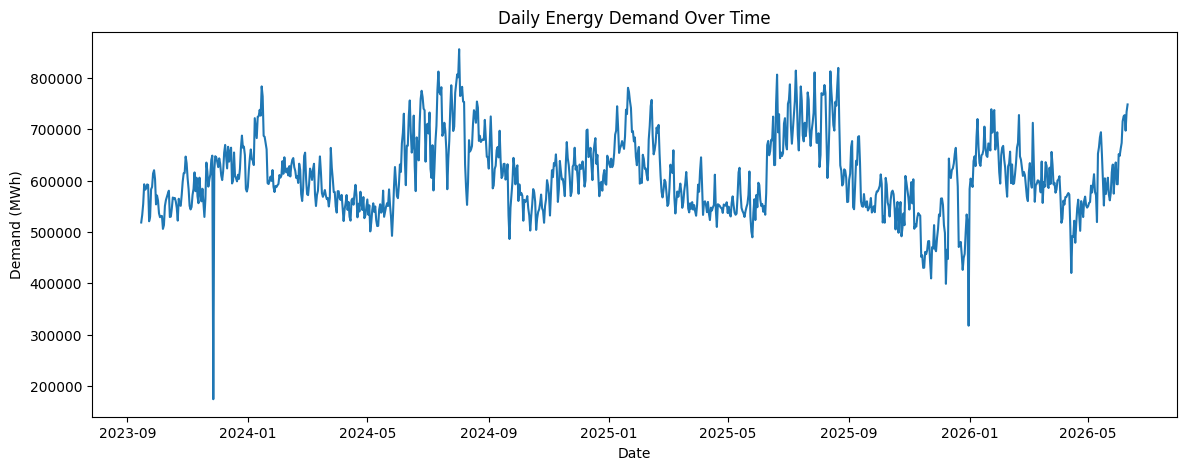

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df_daily.index, df_daily["demand_mwh"])
plt.title("Daily Energy Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (MWh)")
plt.show()

## Seasonal Decomposition

Decomposing the time series into **trend**, **seasonal**, and **residual** components reveals underlying patterns. We use an additive model with `period=7` to capture weekly seasonality — energy demand is systematically higher on weekdays and lower on weekends.

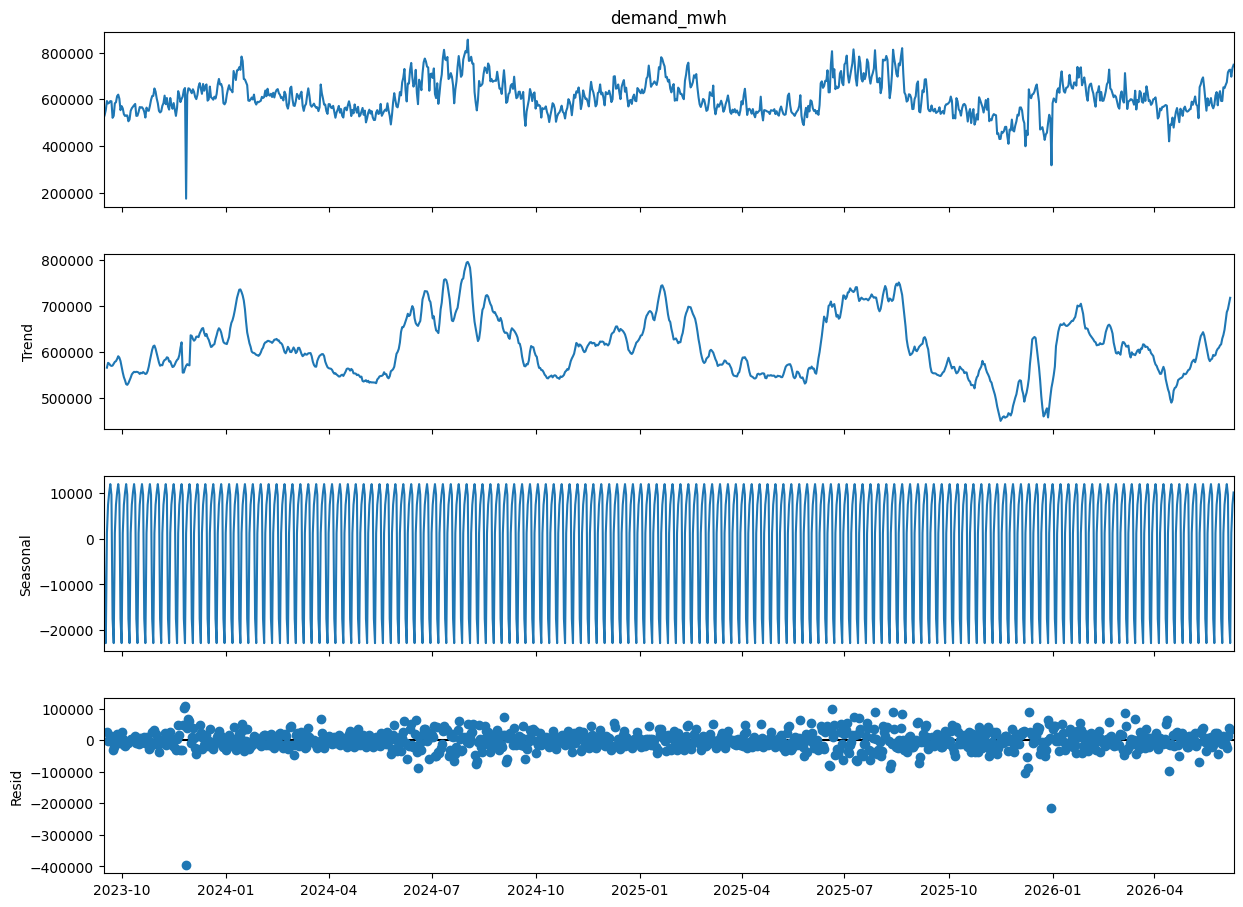

In [134]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# decomposition
result = seasonal_decompose(
    df_daily["demand_mwh"],
    model="additive",
    period=7   # weekly seasonality assumption
)

# plot
fig = result.plot()
fig.set_size_inches(14, 10)

plt.show()

##  Outlier Analysis 

In this section, we detect extreme values in energy consumption using both visualization and the Interquartile Range (IQR) method.

###  Objectives:
- Identify abnormal demand spikes or drops
- Understand variability in the time series
- Assess whether outliers are valid events or data issues
- Support robust modeling decisions (especially for XGBoost and SARIMA)

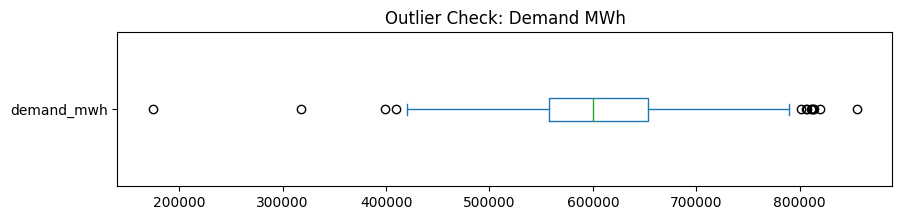

Lower bound: 415574.875
Upper bound: 795195.875


In [135]:
import matplotlib.pyplot as plt

# 1. Visualize outliers using boxplot
df_daily["demand_mwh"].plot(
    kind="box",
    vert=False,
    figsize=(10, 2),
    title="Outlier Check: Demand MWh"
)
plt.show()

# 2. Calculate IQR bounds
Q1 = df_daily["demand_mwh"].quantile(0.25)
Q3 = df_daily["demand_mwh"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

In [136]:
# Identify and count outliers
outliers = df_daily[
    (df_daily["demand_mwh"] < lower_bound) |
    (df_daily["demand_mwh"] > upper_bound)
]

print(f"Total number of outliers detected: {len(outliers)}")

# Add time features for analysis
outliers = outliers.copy()
outliers["day_of_week"] = outliers.index.dayofweek

print("\nOutlier samples (demand + day_of_week):")
print(outliers[["demand_mwh", "day_of_week"]].head())

Total number of outliers detected: 13

Outlier samples (demand + day_of_week):
            demand_mwh  day_of_week
period                             
2023-11-27      174313            0
2024-07-12      812172            4
2024-07-31      806743            2
2024-08-01      800949            3
2024-08-02      855667            4


#### Outliers were identified using the IQR method and found to be minimal in proportion. Given the energy forecasting context, these extreme values likely represent real demand events rather than data errors. Therefore, they were either retained or optionally clipped depending on the modeling approach.


In [137]:
print(df_daily.columns)

Index(['demand_mwh'], dtype='str')


ADF Statistic: -3.2362631942501063
p-value: 0.017979267820116027
Series is stationary


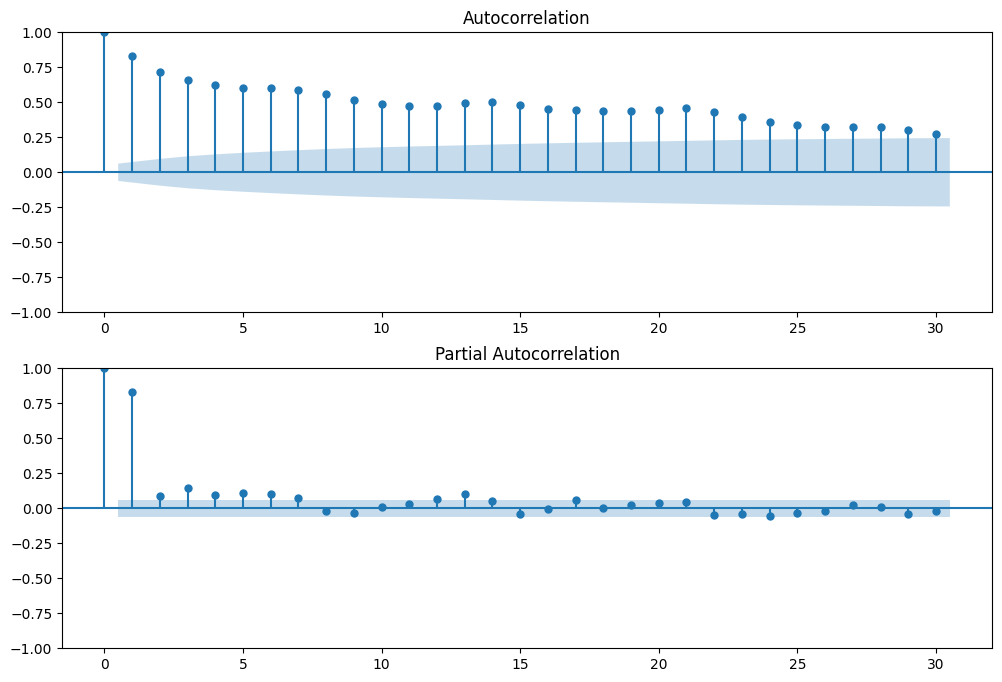

In [138]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ADF Test for Stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Series is stationary")
    else:
        print("Series is NOT stationary (needs differencing)")

check_stationarity(df_daily['demand_mwh'])

#  ACF and PACF plots to identify AR/MA terms
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_daily['demand_mwh'], ax=ax1, lags=30)
plot_pacf(df_daily['demand_mwh'], ax=ax2, lags=30)
plt.show()

#### ADF Test Interpretation

| Result | Meaning |
|--------|---------|
| **p-value ≤ 0.05** | Series is **stationary** — reject unit-root hypothesis |
| **p-value > 0.05** | Series is **non-stationary** — needs differencing for ARIMA |

Stationarity is required by ARIMA-family models but **not by XGBoost** — tree-based models capture temporal patterns directly through lag and rolling features.

**ACF / PACF reading guide:**
- Significant spikes at lags **7, 14, 21** → strong **weekly seasonality**, confirming our lag feature choices
- PACF cuts off sharply at lag *p* → AR(*p*) order
- Slow ACF decay → trend still present, consider first-differencing before fitting ARIMA

### Baseline Model: Seasonal Naive Forecast

In this section, we implement a Seasonal Naive baseline model, where the prediction for each time step is taken from the value observed exactly 7 days earlier. This approach captures weekly seasonality in a simple but effective way.

#### Purpose
- Serve as a baseline benchmark for model comparison
- Capture weekly seasonal patterns without complex modeling
- Provide a reference performance for advanced models like SARIMA and XGBoost

The **Seasonal Naive** forecast uses the demand from *exactly 7 days ago* as the prediction for day *t*:

$$\hat{y}_t = y_{t-7}$$

This trivially captures the weekly seasonal cycle and sets the **minimum performance bar** any advanced model must beat.

In [ ]:
import time
import mlflow
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from src.config import config

mlflow.set_experiment(config.MLFLOW_EXPERIMENT_NAME)

# Shift on the full series so days at the boundary correctly reach into
# the training tail (e.g. first test day's lag-7 = last-7th training day).
df_naive = df_daily.copy()
df_naive["naive_forecast"] = df_naive["demand_mwh"].shift(7)
df_naive_test = df_naive.iloc[split_idx:].dropna()

t0 = time.perf_counter()
naive_preds = df_naive_test["naive_forecast"].values
latency_naive_ms = (time.perf_counter() - t0) * 1000

rmse_baseline = np.sqrt(mean_squared_error(df_naive_test["demand_mwh"], naive_preds))
mae_baseline  = mean_absolute_error(df_naive_test["demand_mwh"], naive_preds)

print(f"Seasonal Naive — RMSE: {rmse_baseline:.2f} | MAE: {mae_baseline:.2f} | Latency: {latency_naive_ms:.3f} ms")

with mlflow.start_run(run_name="seasonal_naive"):
    mlflow.set_tag("source", "notebook_eda")
    mlflow.set_tag("model_type", "baseline")
    mlflow.log_param("lag_days", 7)
    mlflow.log_param("test_size", len(df_naive_test))
    mlflow.log_metric("test_rmse",        rmse_baseline)
    mlflow.log_metric("test_mae",         mae_baseline)
    mlflow.log_metric("latency_ms",       latency_naive_ms)
    mlflow.log_metric("model_size_bytes", 0)

### SARIMA Model (Auto ARIMA)

In this section, we train a Seasonal ARIMA (SARIMA) model using an automated parameter search (auto_arima). The model is trained on the training set and evaluated on a hold-out test set.

#### Objectives
- Capture both trend and weekly seasonality in the data
- Automatically select optimal (p, d, q) and (P, D, Q) parameters using AIC minimization
- Compare performance against the Seasonal Naive baseline

#### Model Setup
- Seasonal period (m) = 7 (weekly seasonality)
- Box-Cox transformation applied for variance stabilization
- Stepwise search used for efficiency

In [ ]:
import pickle
import time
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error

# Use the shared split — same dates as every other model
train_sarima = train_daily["demand_mwh"]
test_sarima  = test_daily["demand_mwh"]

model_sarima = auto_arima(
    train_sarima,
    seasonal=True, m=7, boxcox=True,
    stepwise=True, trace=True,
    suppress_warnings=True, error_action="ignore",
)

t0 = time.perf_counter()
forecast_sarima = model_sarima.predict(n_periods=len(test_sarima))
latency_sarima_ms = (time.perf_counter() - t0) * 1000

rmse_sarima      = np.sqrt(mean_squared_error(test_sarima, forecast_sarima))
mae_sarima       = mean_absolute_error(test_sarima, forecast_sarima)
size_sarima_bytes = len(pickle.dumps(model_sarima))

print(f"\n--- SARIMA Performance (same hold-out as Naive) ---")
print(f"Baseline RMSE : {rmse_baseline:.2f}")
print(f"SARIMA RMSE   : {rmse_sarima:.2f}  |  MAE: {mae_sarima:.2f}")
print(f"Latency       : {latency_sarima_ms:.2f} ms")
print(f"Model size    : {size_sarima_bytes:,} bytes")

with mlflow.start_run(run_name="sarima"):
    mlflow.set_tag("source", "notebook_eda")
    mlflow.set_tag("model_type", "sarima")
    mlflow.log_params({
        "order":          str(model_sarima.order),
        "seasonal_order": str(model_sarima.seasonal_order),
        "boxcox":         True,
        "m":              7,
        "test_size":      len(test_sarima),
    })
    mlflow.log_metric("test_rmse",        rmse_sarima)
    mlflow.log_metric("test_mae",         mae_sarima)
    mlflow.log_metric("latency_ms",       latency_sarima_ms)
    mlflow.log_metric("model_size_bytes", size_sarima_bytes)

### XGBoost Feature Engineering

In this section, we transform the time series dataset into a supervised machine learning format. Unlike SARIMA, XGBoost requires manually engineered features such as lag variables, rolling statistics, and calendar-based features.

Additionally, weather data is incorporated to capture external factors affecting energy demand.

In [ ]:
# Import create_features from src/ instead of duplicating it here.
# Keeping a local copy would silently diverge from production whenever
# src/features.py is updated.
from src.features import create_features

In [ ]:
from src.features import add_weather_features

# Use config values — avoids hardcoded lat/lon drifting out of sync
df_with_weather = add_weather_features(
    df_daily,
    lat=config.GRID_LAT,
    lon=config.GRID_LON,
)

df_features = create_features(df_with_weather)
df_features = df_features.dropna()

In [ ]:
X = df_features.drop(columns=["demand_mwh"])
y = df_features["demand_mwh"]

# Align XGBoost's feature-level split with the shared hold-out cutoff.
# Note: df_features has NaN rows dropped, so use the date index, not split_idx.
X_train_feat = X[X.index <= train_cutoff]
X_test_feat  = X[X.index >  train_cutoff]
y_train_feat = y[y.index <= train_cutoff]
y_test_feat  = y[y.index >  train_cutoff]

print(f"XGBoost — train: {len(X_train_feat)} rows | test: {len(X_test_feat)} rows")

In [ ]:
# ── Correlation Analysis ──────────────────────────────────────────────────────
import seaborn as sns

cols_for_corr = [
    "demand_mwh", "temperature",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7d", "rolling_mean_14d",
    "day_of_week", "month", "is_weekend", "is_holiday",
]
corr_df = df_features[cols_for_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: temperature vs demand (U-curve expected — high demand in both summer & winter)
axes[0].scatter(df_features["temperature"], df_features["demand_mwh"],
                alpha=0.35, s=12, color="steelblue")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Demand (MWh)")
axes[0].set_title("Temperature vs Demand")
axes[0].grid(alpha=0.3)

# Heatmap
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1], vmin=-1, vmax=1, center=0,
            linewidths=0.4, annot_kws={"size": 7})
axes[1].set_title("Feature Correlation Heatmap")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Correlations with demand_mwh (|r|, descending):")
print(corr_df["demand_mwh"].drop("demand_mwh").abs().sort_values(ascending=False).round(3))

In [ ]:
import xgboost as xgb
import pickle, time
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

XGB_PARAMS = dict(
    objective="reg:squarederror",
    max_depth=5, learning_rate=0.05, n_estimators=200, random_state=42,
)

# ── 5-fold CV on training set only (no hold-out leakage) ─────────────────────
tscv = TimeSeriesSplit(n_splits=5)   # matches src/train.py
rmse_scores, mae_scores = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_feat), start=1):
    X_tr, X_val = X_train_feat.iloc[tr_idx], X_train_feat.iloc[val_idx]
    y_tr, y_val = y_train_feat.iloc[tr_idx], y_train_feat.iloc[val_idx]

    m = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(X_tr, y_tr)
    p = m.predict(X_val)

    rmse_scores.append(np.sqrt(mean_squared_error(y_val, p)))
    mae_scores.append(mean_absolute_error(y_val, p))
    print(f"Fold {fold} — RMSE: {rmse_scores[-1]:.2f} | MAE: {mae_scores[-1]:.2f}")

print(f"\nCV mean — RMSE: {np.mean(rmse_scores):.2f} | MAE: {np.mean(mae_scores):.2f}")

# ── Final model: train on full training set, evaluate on hold-out ─────────────
final_xgb = xgb.XGBRegressor(**XGB_PARAMS)
final_xgb.fit(X_train_feat, y_train_feat)

rmse_xgb_train = np.sqrt(mean_squared_error(y_train_feat, final_xgb.predict(X_train_feat)))

t0 = time.perf_counter()
xgb_test_preds = final_xgb.predict(X_test_feat)
latency_xgb_ms = (time.perf_counter() - t0) * 1000

rmse_xgb_test   = np.sqrt(mean_squared_error(y_test_feat, xgb_test_preds))
mae_xgb_test    = mean_absolute_error(y_test_feat, xgb_test_preds)
size_xgb_bytes  = len(pickle.dumps(final_xgb))
overfit_ratio   = rmse_xgb_test / rmse_xgb_train

print(f"\n--- XGBoost Hold-Out ---")
print(f"Train RMSE : {rmse_xgb_train:.2f}  →  Test RMSE: {rmse_xgb_test:.2f}")
print(f"Overfitting ratio: {overfit_ratio:.2f}×  (>2.0 = suspicious)")
print(f"Test MAE   : {mae_xgb_test:.2f}")
print(f"Latency    : {latency_xgb_ms:.3f} ms")
print(f"Model size : {size_xgb_bytes:,} bytes")

with mlflow.start_run(run_name="xgboost"):
    mlflow.set_tag("source", "notebook_eda")
    mlflow.set_tag("model_type", "xgboost")
    mlflow.log_params({**XGB_PARAMS, "cv_n_splits": 5, "test_size": len(X_test_feat)})
    mlflow.log_metric("cv_mean_rmse",     np.mean(rmse_scores))
    mlflow.log_metric("cv_mean_mae",      np.mean(mae_scores))
    mlflow.log_metric("train_rmse",       rmse_xgb_train)
    mlflow.log_metric("test_rmse",        rmse_xgb_test)
    mlflow.log_metric("test_mae",         mae_xgb_test)
    mlflow.log_metric("overfitting_ratio",overfit_ratio)
    mlflow.log_metric("latency_ms",       latency_xgb_ms)
    mlflow.log_metric("model_size_bytes", size_xgb_bytes)

In [ ]:
# ── Prediction vs Actual — Hold-Out Test Set ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(y_test_feat.index, y_test_feat.values,
             label="Actual", color="steelblue", linewidth=1.5)
axes[0].plot(y_test_feat.index, xgb_test_preds,
             label="Predicted", color="darkorange", linestyle="--", linewidth=1.5)
axes[0].set_title("XGBoost — Actual vs Predicted (Hold-Out Test Set)")
axes[0].set_ylabel("Demand (MWh)")
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = y_test_feat.values - xgb_test_preds
axes[1].fill_between(range(len(residuals)), residuals, alpha=0.5, color="steelblue")
axes[1].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[1].set_title("Residuals (Actual − Predicted)")
axes[1].set_ylabel("Error (MWh)")
axes[1].set_xlabel("Test sample index")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Test RMSE: {rmse_xgb_test:.2f} | MAE: {mae_xgb_test:.2f}")
print(f"Max over-prediction : {residuals.min():.0f} MWh")
print(f"Max under-prediction: {residuals.max():.0f} MWh")

In [ ]:
# ── Feature Importance ────────────────────────────────────────────────────────
importances = pd.Series(final_xgb.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("XGBoost Feature Importance (F-score Gain — trained on train set)", fontsize=13)
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.sort_values(ascending=False).head(5).round(4))

In [ ]:
# ── Final Model Comparison — same hold-out, same metrics ─────────────────────
comparison = pd.DataFrame({
    "Model":          ["Seasonal Naive", "SARIMA", "XGBoost"],
    "Test RMSE":      [round(rmse_baseline), round(rmse_sarima), round(rmse_xgb_test)],
    "Test MAE":       [round(mae_baseline),  round(mae_sarima),  round(mae_xgb_test)],
    "RMSE Δ Baseline":["—",
                        f"{rmse_baseline - rmse_sarima:+.0f}",
                        f"{rmse_baseline - rmse_xgb_test:+.0f}"],
    "Improvement %":  ["—",
                        f"{(rmse_baseline-rmse_sarima)/rmse_baseline*100:.1f}%",
                        f"{(rmse_baseline-rmse_xgb_test)/rmse_baseline*100:.1f}%"],
    "Latency (ms)":   [f"{latency_naive_ms:.2f}",
                        f"{latency_sarima_ms:.2f}",
                        f"{latency_xgb_ms:.2f}"],
    "Size (bytes)":   ["0", f"{size_sarima_bytes:,}", f"{size_xgb_bytes:,}"],
    "Overfitting":    ["n/a", "n/a", f"{overfit_ratio:.2f}×"],
})

print("=" * 95)
print("MODEL COMPARISON — all three models evaluated on the identical hold-out test set")
print("=" * 95)
print(comparison.to_string(index=False))
print("=" * 95)

xgb_gain    = (rmse_baseline - rmse_xgb_test) / rmse_baseline * 100
sarima_gain = (rmse_baseline - rmse_sarima)   / rmse_baseline * 100

print(f"\n→ XGBoost : {xgb_gain:.1f}% RMSE gain over baseline | fast ({latency_xgb_ms:.1f} ms) | compact ({size_xgb_bytes:,} bytes)")
print(f"→ SARIMA  : {sarima_gain:.1f}% RMSE gain for dramatically more complexity and {latency_sarima_ms:.0f} ms latency")
print(f"→ Overfitting check: XGBoost train/test ratio = {overfit_ratio:.2f}× (healthy if < 1.5)")
print(f"\nProduction choice → XGBoost  (accuracy + speed + size + generalization)")